In [1]:
import pandas as pd
import seaborn as sns
import matplotlib
matplotlib.use("Agg") 
%matplotlib inline
import matplotlib.pyplot as plt
import argparse  
import sqlite3
from threading import Thread

cnx = sqlite3.connect('./data_copy.db')
try:
    cnx.execute('''
            CREATE INDEX IF NOT EXISTS idx_elasticity_lookup 
            ON data (experiment, provider, date_time, language, cpu, memory, timestamp)
    ''')
    cnx.commit()
    print("Index created/verified")
except Exception as e:
    print(f"Index creation note: {e}")

Index created/verified


python(65470) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


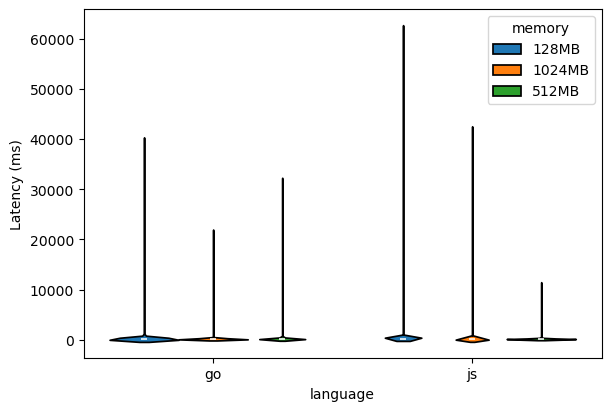

In [3]:
%matplotlib inline
x = 'language'
hue = 'memory'
provider = 'awsARM'

query = f"SELECT * FROM data WHERE provider LIKE '{provider}' AND experiment LIKE 'warmstart' and cold_starts = 0"
#set file name with hue
df = pd.read_sql_query(query, cnx)
p99 = df['http_req_waiting'].quantile(0.99)
df = df[df['http_req_waiting'] >= p99]
    
if df.empty:
    print(f'empty dataframe')

fig, ax = plt.subplots(figsize=(6,4), constrained_layout=True)

order = sorted(df[x].unique())
    
sns.violinplot(
    x=x,
    y='http_req_waiting',
    hue=hue,
    data=df,
    saturation=1,
    linecolor="black",
    order=order,
    ax=ax
)
    
ax.set_ylabel("Latency (ms)")
ax.set_xlabel(x)
    
plt.show()

In [4]:
query_google = "select * from data where provider = 'google' and experiment = 'warmstart' and cold_starts = 0"
df_google = pd.read_sql_query(query_google, cnx)

df_google["date_time"] = df_google['date_time'].str[0:10]

p99 = df['http_req_waiting'].quantile(0.99)
df_google_above_p99 = df_google[df_google['http_req_waiting'] <= p99]

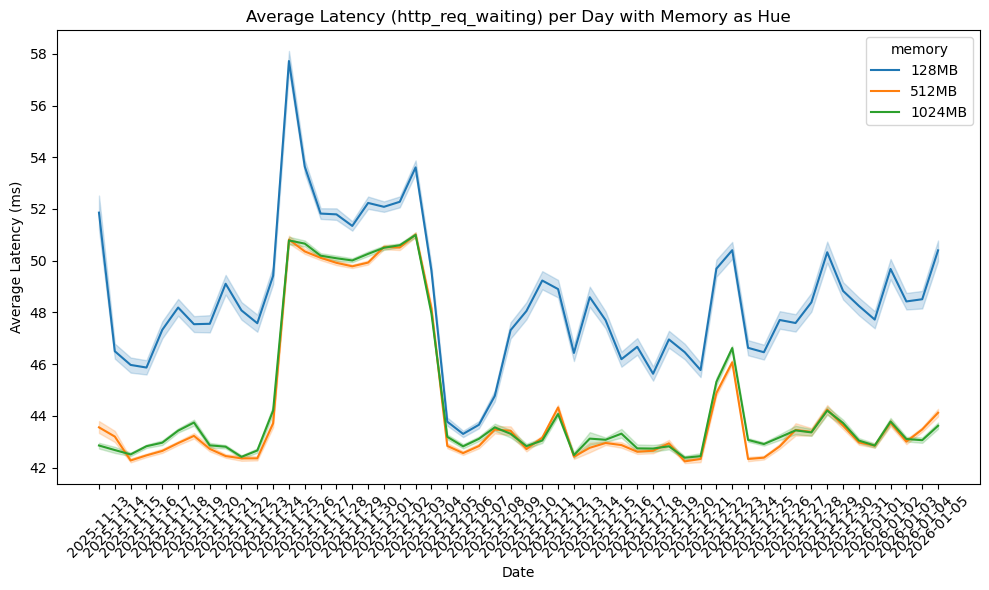

In [5]:
# Plot the average latency with memory as a hue
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_google_above_p99, x='date_time', y='http_req_waiting', hue='memory', ax=ax)

ax.set_title('Average Latency (http_req_waiting) per Day with Memory as Hue')
ax.set_xlabel('Date')
ax.set_ylabel('Average Latency (ms)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# INTERESTING: 1024MB and 512 behave very similar in comparison to 128 for google warmst

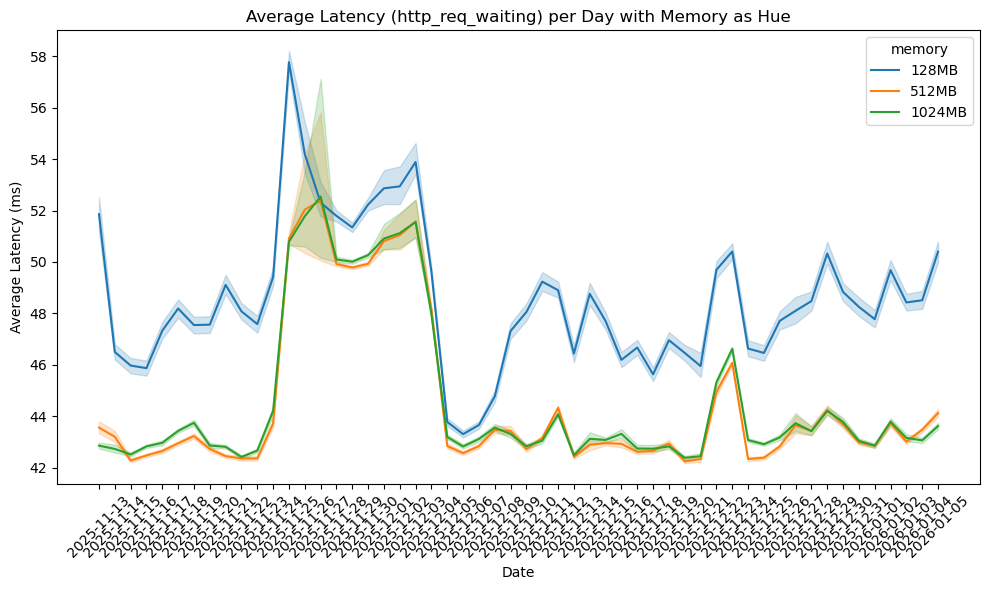

In [6]:
# Plot the average latency with memory as a hue
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=df_google, x='date_time', y='http_req_waiting', hue='memory', ax=ax)

ax.set_title('Average Latency (http_req_waiting) per Day with Memory as Hue')
ax.set_xlabel('Date')
ax.set_ylabel('Average Latency (ms)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# INTERESTING

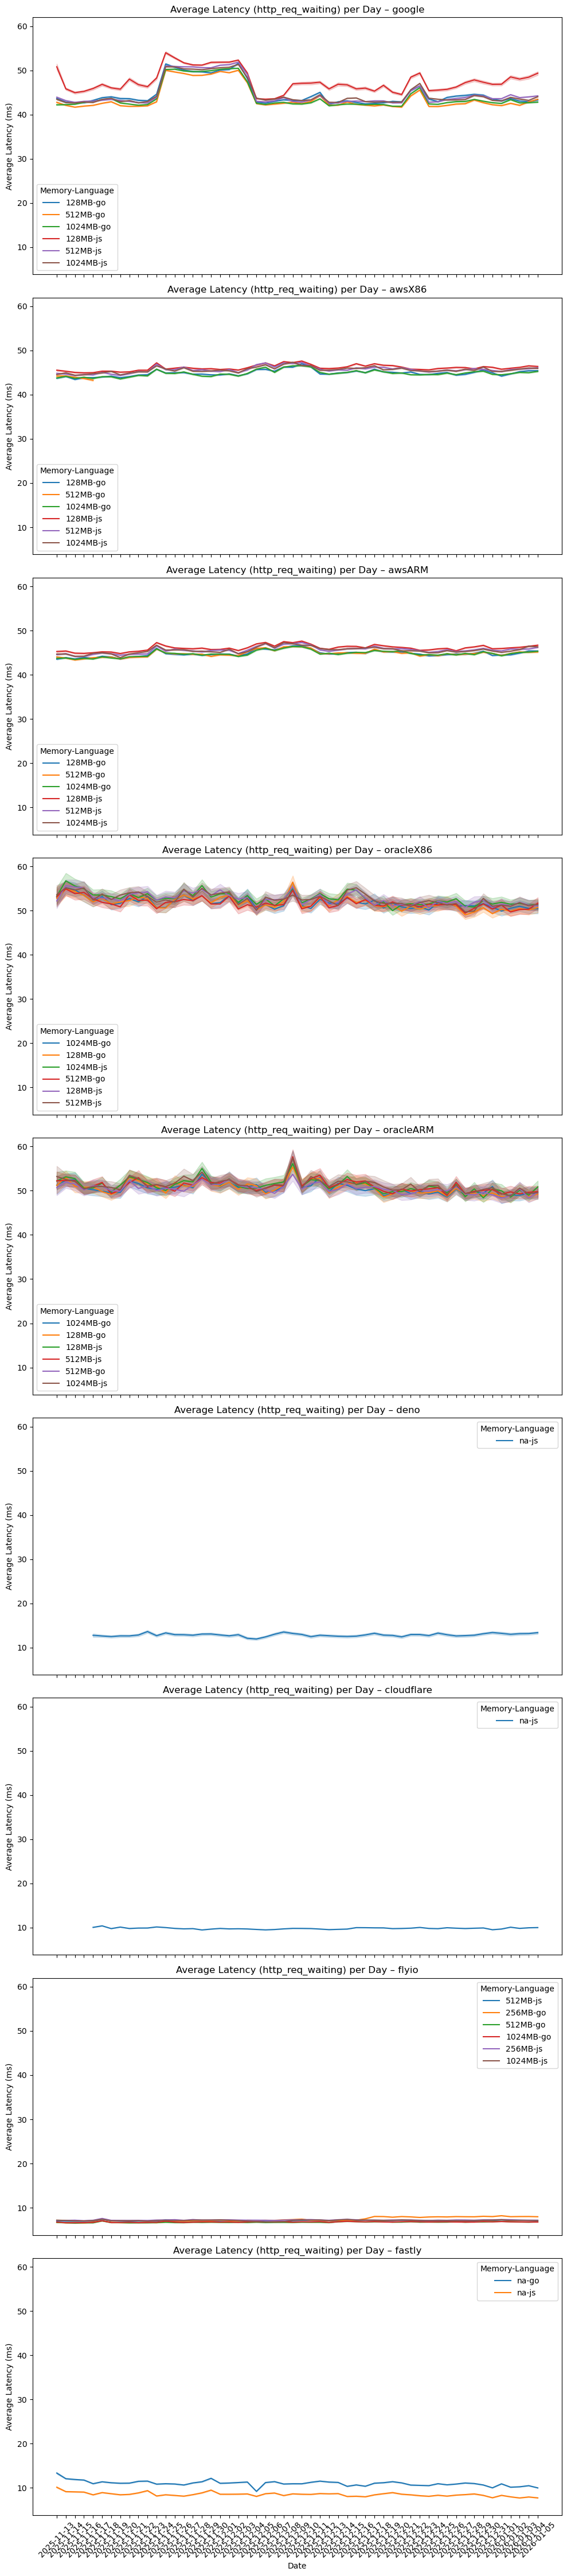

In [21]:
# Define the providers you want to plot
providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]  # <-- edit this list

# Number of subplots
n_providers = len(providers)

fig, axes = plt.subplots(
    nrows=n_providers,
    ncols=1,
    figsize=(10, 5 * n_providers),
    sharex=True,
    sharey=True
)

# If only one provider, axes is not iterable
if n_providers == 1:
    axes = [axes]

for ax, provider in zip(axes, providers):
    if provider == 'fastly':
        df_provider = pd.read_sql(f"select * from data where provider = '{provider}' and experiment = 'warmstart'", cnx)
    else:    
        df_provider = pd.read_sql(f"select * from data where provider = '{provider}' and experiment = 'warmstart' and cold_starts = 0", cnx)
    df_provider["date_time"] = df_provider["date_time"].str[0:10]

    p99 = df_provider["http_req_waiting"].quantile(0.99)
    df_provider = df_provider[df_provider["http_req_waiting"] <= p99]
    
    df_provider["hue"] = df_provider["memory"] + "-" + df_provider['language']
    
    sns.lineplot(
        data=df_provider,
        x="date_time",
        y="http_req_waiting",
        hue="hue",
        ax=ax
    )

    ax.set_title(f"Average Latency (http_req_waiting) per Day – {provider}")
    ax.set_ylabel("Average Latency (ms)")
    ax.legend(title="Memory-Language")

axes[-1].set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Got dataframe, aggregating and visualizing now...


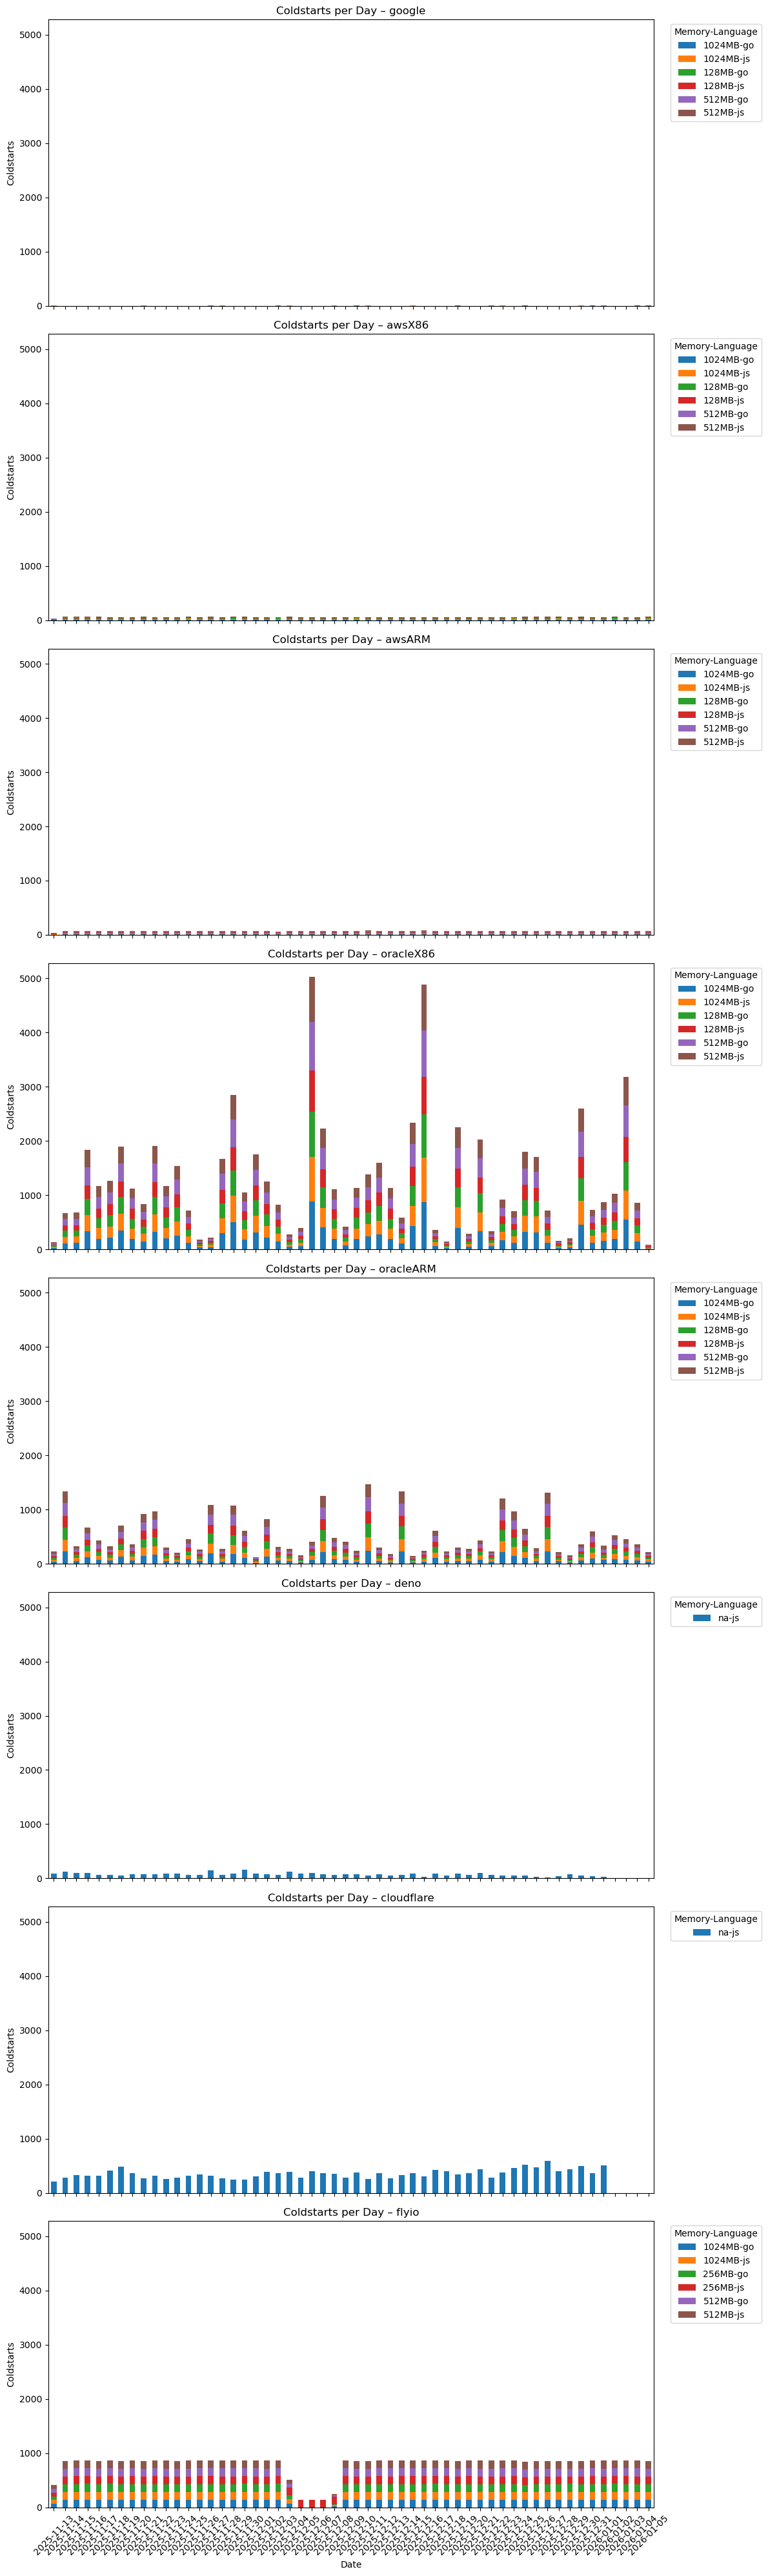

In [22]:
# How many coldstarts occurred each day for each provider during the warmstart experiment

# Define the providers you want to plot
providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio"]  # <-- edit this list

# Number of subplots
n_providers = len(providers)

fig, axes = plt.subplots(
    nrows=n_providers,
    ncols=1,
    figsize=(12, 5 * n_providers),
    sharex=True,
    sharey=True
)

# If only one provider, axes is not iterable
if n_providers == 1:
    axes = [axes]
    
df = pd.read_sql(f"select * from data where experiment = 'warmstart'", cnx)

print("Got dataframe, aggregating and visualizing now...")

for ax, provider in zip(axes, providers):
    
    if provider == 'fastly':
        continue
    
    df_provider = df[df["provider"] == provider].copy()
    df_provider["date_time"] = df_provider["date_time"].str[0:10]

    # Aggregate cold starts per day, memory, and language
    daily_coldstarts = (
        df_provider.groupby(["date_time", "memory", "language"], as_index=False)
          .agg(coldstarts_per_day=("cold_starts", "sum"))
    )

    # Create combined hue and pivot for stacked bar
    daily_coldstarts["hue"] = daily_coldstarts["memory"].astype(str) + "-" + daily_coldstarts["language"].astype(str)
    pivot = (
        daily_coldstarts
        .pivot(index="date_time", columns="hue", values="coldstarts_per_day")
        .fillna(0)
        .sort_index()
    )

    # Stacked bar plot
    pivot.plot(kind="bar", stacked=True, ax=ax)

    ax.set_title(f"Coldstarts per Day – {provider}")
    ax.set_ylabel("Coldstarts")
    ax.legend(title="Memory-Language", bbox_to_anchor=(1.02, 1), loc="upper left")

axes[-1].set_xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

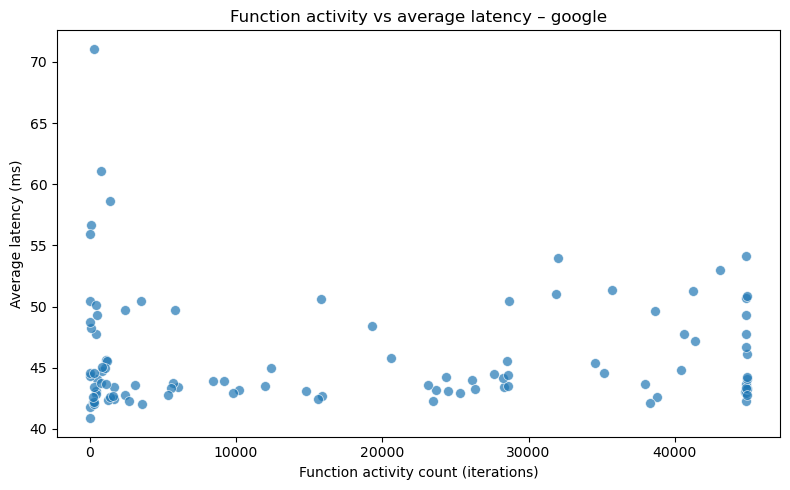

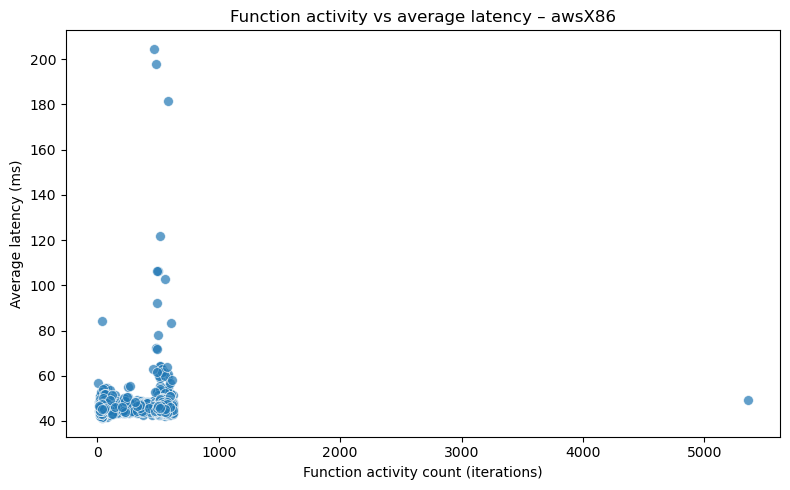

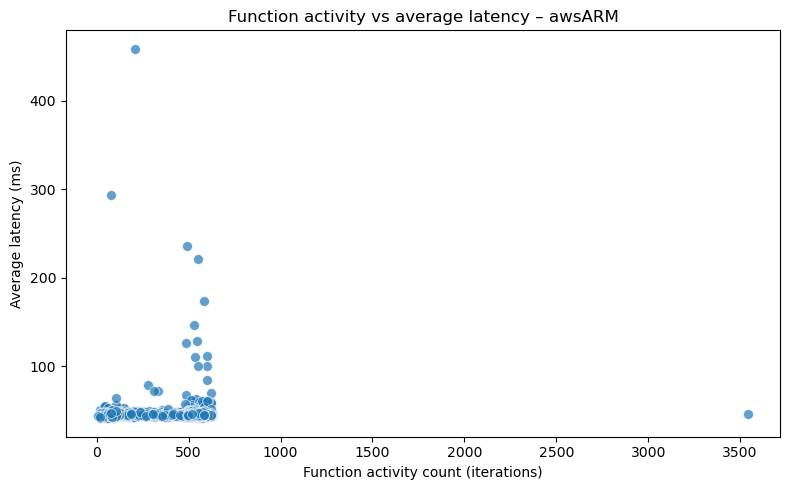

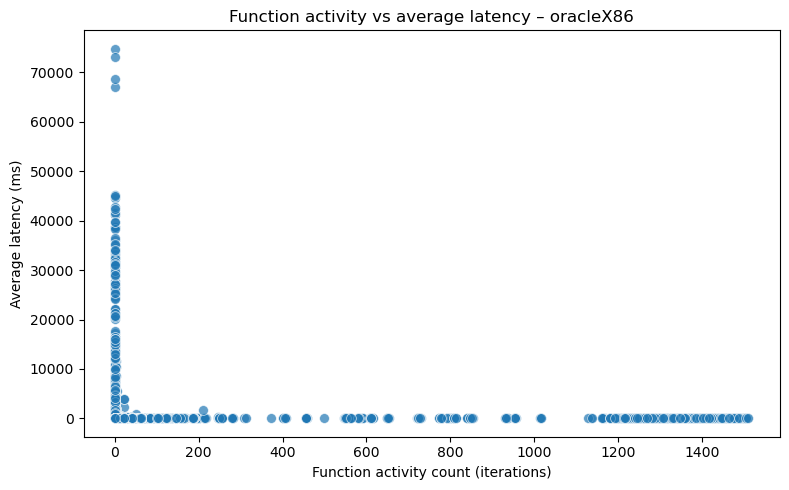

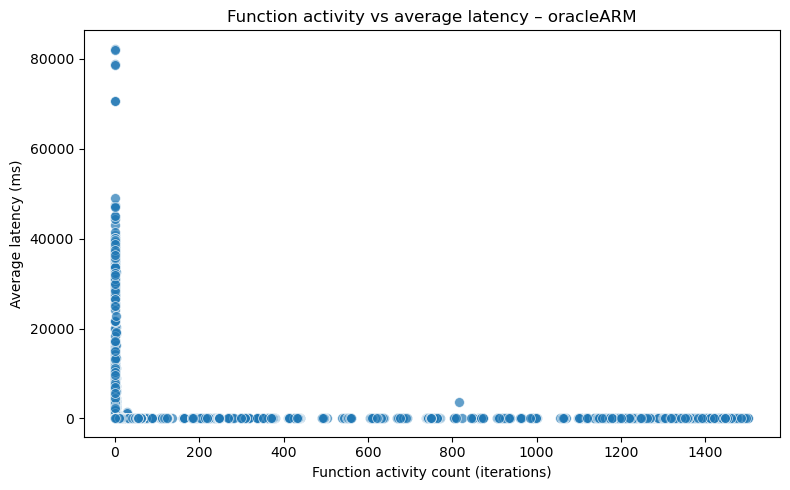

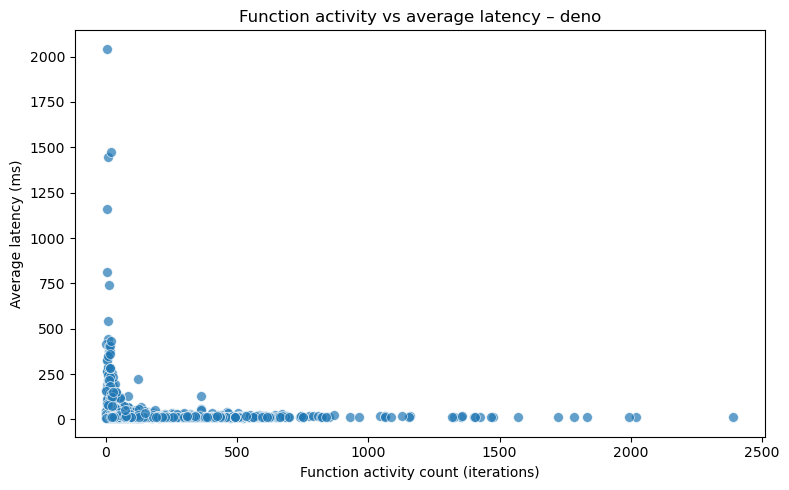

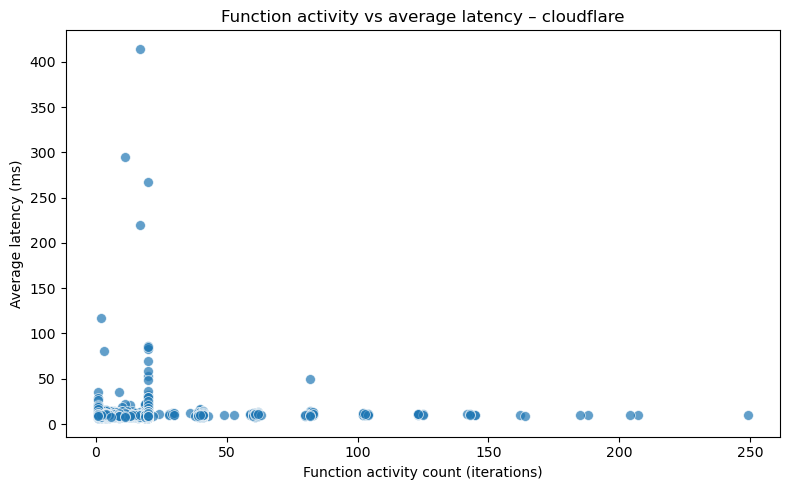

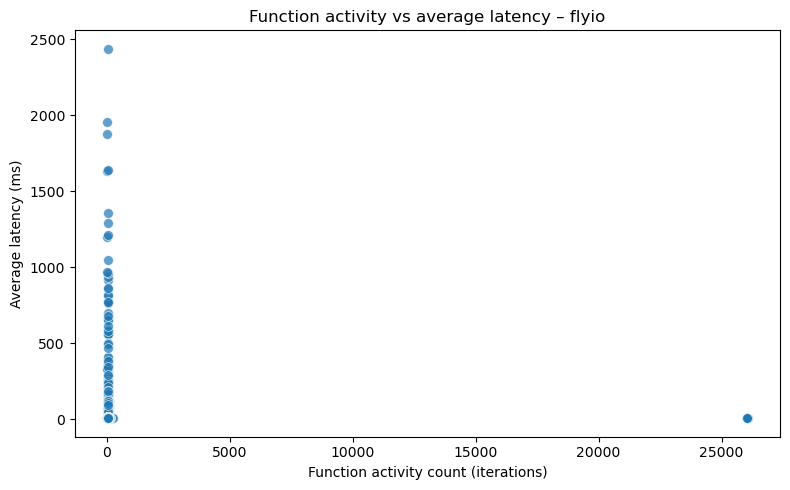

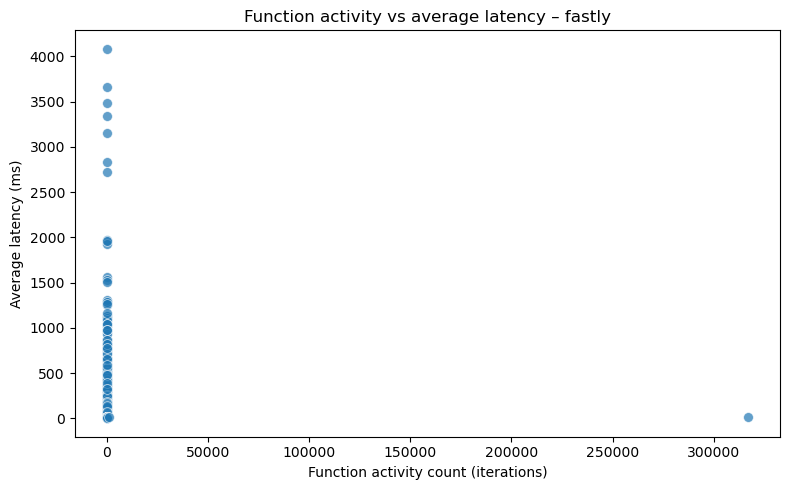

In [2]:
# Correlation between function activity count and average latency (scatter per provider)

# Providers to include
providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]  # <-- edit this list

# Latency metric to analyze
metric_col = "http_req_waiting"

for provider in providers:
    if provider == "fastly":
        query = f"select * from data where provider = '{provider}' and experiment = 'warmstart'"
    else:
        query = f"select * from data where provider = '{provider}' and experiment = 'warmstart' and cold_starts = 0"

    df_provider = pd.read_sql_query(query, cnx)
    if df_provider.empty:
        print(f"No rows for provider: {provider}")
        continue

    df_provider = df_provider.dropna(subset=["functionId", metric_col])

    # Count how often each function appears (activity) and compute average latency
    df_fn = (
        df_provider.groupby("functionId", as_index=False)
        .agg(
            activity_count=("functionId", "size"),
            avg_latency=(metric_col, "mean")
        )
    )

    if df_fn.empty:
        print(f"No function-level data for provider: {provider}")
        continue

    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=df_fn,
        x="activity_count",
        y="avg_latency",
        s=50,
        alpha=0.7
    )

    plt.title(f"Function activity vs average latency – {provider}")
    plt.xlabel("Function activity count (iterations)")
    plt.ylabel("Average latency (ms)")
    plt.tight_layout()
    plt.show()


/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65226/2464993879.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


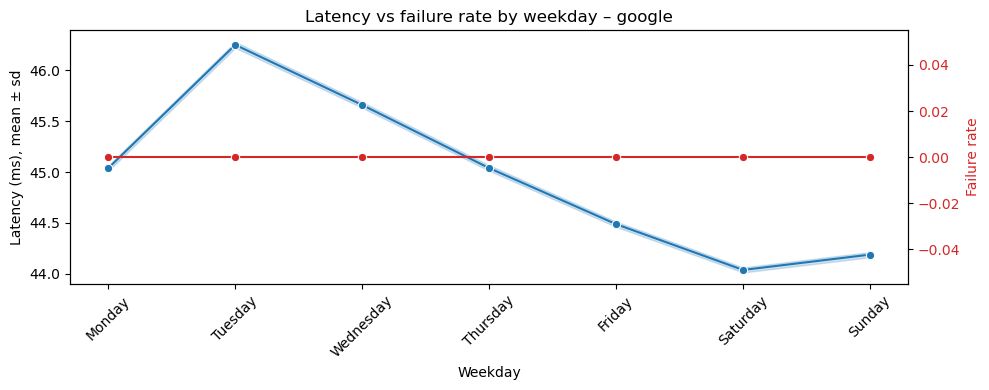

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65226/2464993879.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


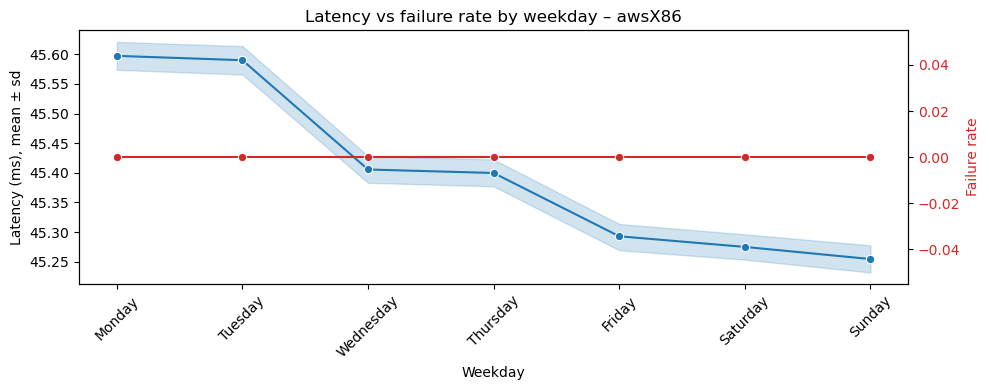

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65226/2464993879.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


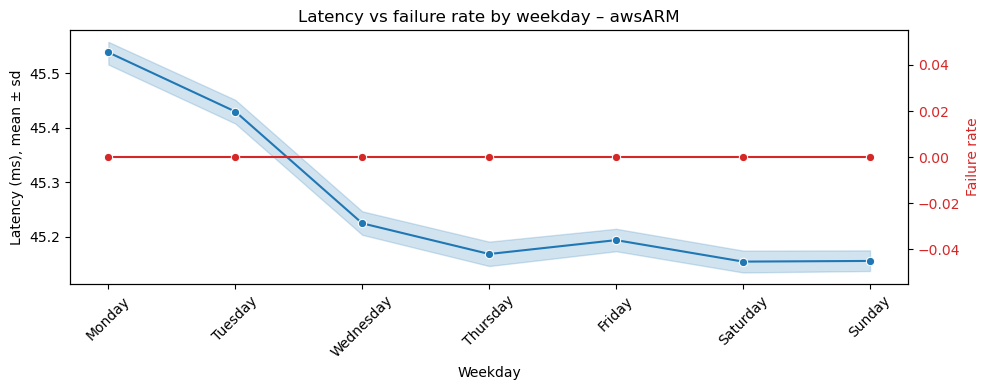

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65226/2464993879.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


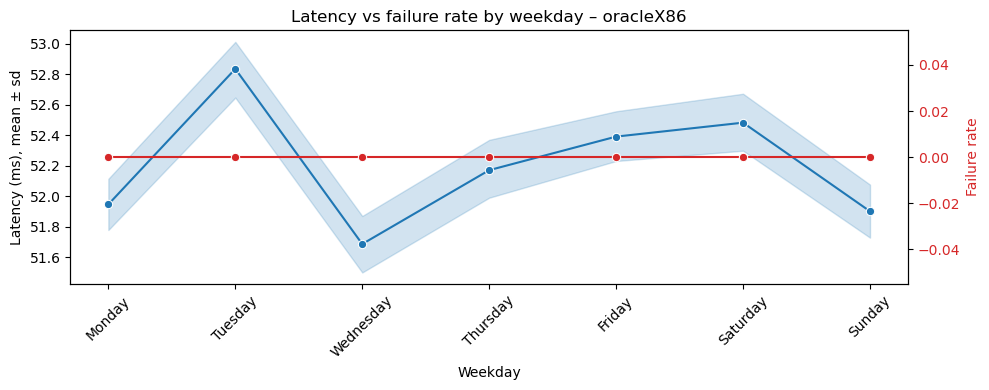

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65226/2464993879.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


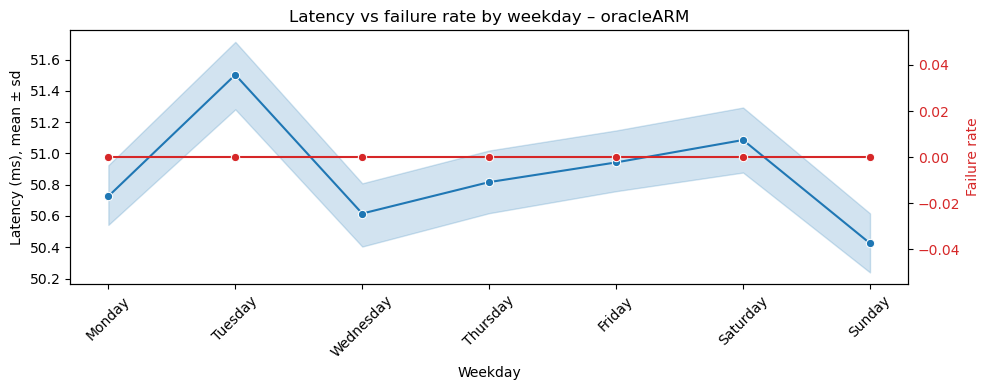

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65226/2464993879.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


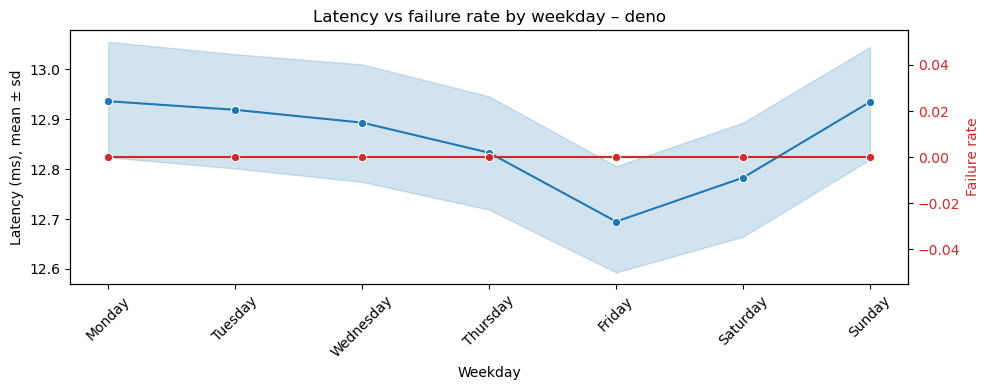

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65226/2464993879.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


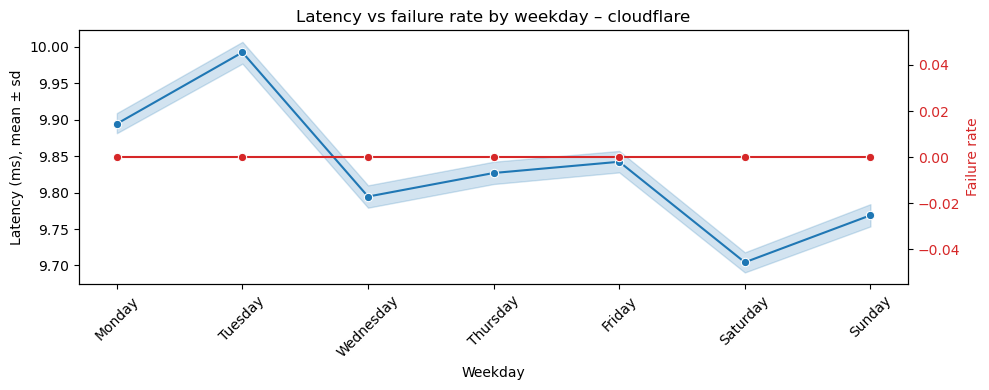

/var/folders/vb/5k3fnx_51xg3y2jpq3w3vm500000gn/T/ipykernel_65226/2464993879.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_provider.groupby("weekday", as_index=False)


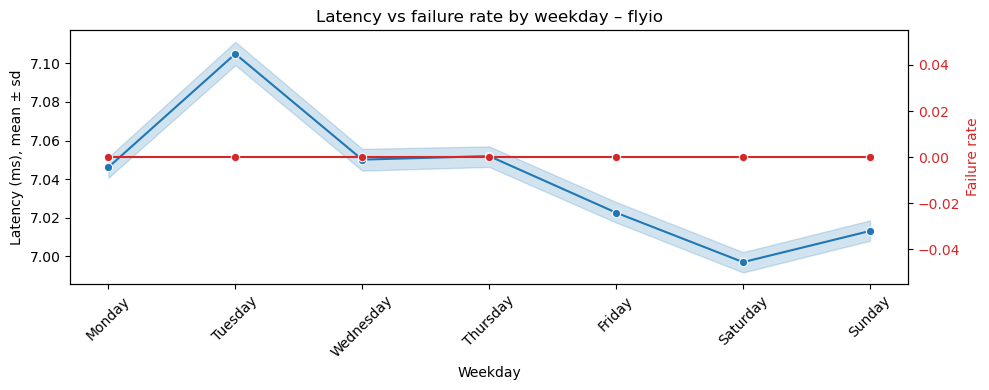

In [4]:
# Weekday performance vs failure rate (warmstart experiment)

providers = ["google", "awsX86", "awsARM", "oracleX86", "oracleARM", "deno", "cloudflare", "flyio", "fastly"]  # <-- edit this list
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

for provider in providers:
    df_provider = pd.read_sql_query(
        """
        SELECT date_time, http_req_waiting, errorMessage
        FROM data
        WHERE provider = ? AND experiment = 'warmstart' AND cold_starts = 0
        """,
        cnx,
        params=[provider],
    )
    if df_provider.empty:
        continue

    # Parse date; day_name uses locale-aware weekday calculation
    df_provider["date"] = pd.to_datetime(df_provider["date_time"].str[:10], errors="coerce")
    df_provider = df_provider.dropna(subset=["date"])
    df_provider["weekday"] = df_provider["date"].dt.day_name()
    df_provider["weekday"] = pd.Categorical(df_provider["weekday"], categories=weekday_order, ordered=True)

    # Remove latency outliers
    p99 = df_provider["http_req_waiting"].quantile(0.99)
    df_provider = df_provider[df_provider["http_req_waiting"] <= p99]

    # Failure rate by weekday
    agg_fail = (
        df_provider.groupby("weekday", as_index=False)
        .agg(
            total=("http_req_waiting", "size"),
            failures=("errorMessage", lambda s: s.notna().sum()),
        )
        .sort_values("weekday")
    )
    agg_fail["fail_rate"] = (agg_fail["failures"] / agg_fail["total"]).fillna(0)

    fig, ax1 = plt.subplots(figsize=(10, 4))

    # Let seaborn compute mean and variability
    sns.lineplot(
        data=df_provider,
        x="weekday",
        y="http_req_waiting",
        marker="o",
        ax=ax1,
    )
    ax1.set_title(f"Latency vs failure rate by weekday – {provider}")
    ax1.set_ylabel("Latency (ms), mean ± sd")
    ax1.set_xlabel("Weekday")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    sns.lineplot(
        data=agg_fail,
        x="weekday",
        y="fail_rate",
        marker="o",
        color="tab:red",
        ax=ax2,
    )
    ax2.set_ylabel("Failure rate", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.tight_layout()
    plt.show()